# ⚽ FIFA World Cup 2026 — Match Predictor

A machine-learning project that predicts the outcome of international football
matches and simulates the 2026 World Cup, served through a **FastAPI** backend
and a **Streamlit** web app.

**Run order:** execute every cell from top to bottom. The notebook will:
1. Download the data, engineer features, and train the model.
2. Save the model (`model.joblib`) and team ratings (`ratings.pkl`).
3. Write out `main.py` (the API) and `app.py` (the web UI) for you.
4. Tell you the two terminal commands that launch the live app.

**Tech stack:** Python, pandas, scikit-learn, XGBoost, FastAPI, Streamlit.

---

### Libraries required

In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque
import joblib, pickle, random

### Dataset 

In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
matches = pd.read_csv(URL)


In [3]:
matches.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
matches.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49476,2026-06-27,Croatia,Ghana,NaN,NaN,FIFA World Cup,Philadelphia,United States,True


In [5]:
matches["date"] = pd.to_datetime(matches["date"])


matches.info()

### Removing null values

In [6]:
matches.describe()

,date,home_score,away_score
count,49477,49421.000000,49421.000000
mean,1994-05-22 13:38:00.550558720,1.757330,1.181826
min,1872-11-30 00:00:00,0.000000,0.000000
25%,1980-09-09 00:00:00,1.000000,0.000000
50%,2000-07-15 00:00:00,1.000000,1.000000
75%,2013-07-15 00:00:00,2.000000,2.000000
max,2026-06-27 00:00:00,31.000000,21.000000
std,NaN,1.774309,1.401899


In [7]:
matches.isnull().sum()


date           0
home_team      0
away_team      0
home_score    56
away_score    56
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [8]:
matches.isnull().sum().sum()

np.int64(112)

In [9]:
played = matches.dropna(subset=["home_score", "away_score"]).sort_values("date").reset_index(drop=True)
print("Total rows:", len(matches), "| Played:", len(played))

Total rows: 49477 | Played: 49421


In [10]:
played.isnull().sum()


date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

### Feature engineering

### A model can only learn from the numbers you give it. Raw team names mean nothing to it, so we convert each matchup into meaningful numbers. We build two: an Elo rating (overall strength) and recent form.
### Elo is the same system used in chess. Every team starts at 1500. After each match, the winner takes points from the loser. The clever part is how many points: if a 1900-rated team beats a 1500-rated team, that was expected, so little changes. But if the 1500 team wins, it gains a lot — the result was surprising, so it tells us our ratings were wrong.

In [11]:
def expected_score(elo_a, elo_b):
    """Elo formula: probability team A beats team B."""
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

### That formula converts a rating gap into a win probability. A 0-point gap gives 0.5 (coin flip); a 400-point gap gives about 0.9. The 400 is just the scale constant the chess world settled on.

In [12]:
elos = defaultdict(lambda: 1500.0)            # current rating per team
form = defaultdict(lambda: deque(maxlen=5))   # last 5 goal-differences per team
K = 40            # how strongly a result moves the rating
HOME_ADV = 65     # Elo bonus for the home team when NOT on neutral ground

home_elo, away_elo, home_form, away_form = [], [], [], []

for r in played.itertuples():
    h, a = r.home_team, r.away_team
    he, ae = elos[h], elos[a]

    # 1) Record PRE-match values -> these become the features
    home_elo.append(he)
    away_elo.append(ae)
    home_form.append(np.mean(form[h]) if form[h] else 0.0)
    away_form.append(np.mean(form[a]) if form[a] else 0.0)

    # 2) Update ratings using the actual result
    h_adj = he + (0 if r.neutral else HOME_ADV)
    exp_h = expected_score(h_adj, ae)
    if   r.home_score > r.away_score: actual = 1.0
    elif r.home_score == r.away_score: actual = 0.5
    else: actual = 0.0

    change = K * (actual - exp_h)
    elos[h] = he + change
    elos[a] = ae - change
    form[h].append(r.home_score - r.away_score)
    form[a].append(r.away_score - r.home_score)

played["home_elo"]  = home_elo
played["away_elo"]  = away_elo
played["home_form"] = home_form
played["away_form"] = away_form

In [13]:
played["elo_diff"]  = (played["home_elo"] + np.where(played["neutral"], 0, HOME_ADV)) - played["away_elo"]
played["form_diff"] = played["home_form"] - played["away_form"]
played["neutral"]   = played["neutral"].astype(int)

def outcome(r):
    if r["home_score"] > r["away_score"]: return 0   # home win
    if r["home_score"] == r["away_score"]: return 1  # draw
    return 2                                          # away win
played["target"] = played.apply(outcome, axis=1)

FEATURES = ["elo_diff", "home_elo", "away_elo", "neutral", "home_form", "away_form", "form_diff"]
modern = played[played["date"] >= "2000-01-01"].copy()

### Train the model

In [14]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from xgboost import XGBClassifier

train = modern[modern["date"] < "2023-01-01"]
test  = modern[modern["date"] >= "2023-01-01"]

model = XGBClassifier(
    objective="multi:softprob", num_class=3,
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, eval_metric="mlogloss",
)
model.fit(train[FEATURES], train["target"])

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


### XGBoost builds hundreds of small decision trees where each new tree tries to fix the previous ones' mistakes — it's the go-to model for tabular data like this. objective="multi:softprob" tells it we have 3 classes and we want probabilities, not just a single guess. max_depth=4 keeps each tree shallow so the model can't memorize noise (overfitting).
### Notice we split by date, not randomly. We train on everything before 2023 and test on 2023 onward. This answers the honest question: "if I'd built this model in 2022, how well would it predict matches it had never seen?" A random split would let a 2024 match sneak into training and a 2023 one into testing — the model would effectively study for the exam in advance and you'd fool yourself about how good it is.

### Evaluate 

In [16]:
from sklearn.metrics import accuracy_score, log_loss, classification_report

pred  = model.predict(test[FEATURES])
proba = model.predict_proba(test[FEATURES])

print("Model accuracy:", round(accuracy_score(test["target"], pred), 3))
print("Model log loss:", round(log_loss(test["target"], proba), 3))

baseline = (test["elo_diff"] > 0).astype(int).map({1: 0, 0: 2})
print("Baseline accuracy:", round(accuracy_score(test["target"], baseline), 3))
print(classification_report(test["target"], pred, target_names=["home_win","draw","away_win"]))

Model accuracy: 0.6
Model log loss: 0.875
Baseline accuracy: 0.601
              precision    recall  f1-score   support

    home_win       0.61      0.88      0.72      1707
        draw       0.36      0.01      0.02       835
    away_win       0.58      0.62      0.60      1072

    accuracy                           0.60      3614
   macro avg       0.52      0.50      0.45      3614
weighted avg       0.54      0.60      0.52      3614



### Predicting

In [17]:
def predict_match(home, away, neutral=True):
    he = elos.get(home, 1500.0)
    ae = elos.get(away, 1500.0)
    hf = np.mean(form[home]) if form.get(home) else 0.0
    af = np.mean(form[away]) if form.get(away) else 0.0
    elo_diff = (he + (0 if neutral else HOME_ADV)) - ae
    x = pd.DataFrame([[elo_diff, he, ae, int(neutral), hf, af, hf - af]], columns=FEATURES)
    p = model.predict_proba(x)[0]
    return {"home_win": round(float(p[0]),3), "draw": round(float(p[1]),3), "away_win": round(float(p[2]),3)}

print(predict_match("Brazil", "Argentina"))   # -> Argentina slightly favoured
print(predict_match("Spain", "Panama"))        # -> Spain heavily favoured

{'home_win': 0.238, 'draw': 0.274, 'away_win': 0.488}
{'home_win': 0.753, 'draw': 0.184, 'away_win': 0.063}


In [18]:
def predict_winner(home, away, neutral=True):
    p = predict_match(home, away, neutral)
    winner = home if p["home_win"] >= p["away_win"] else away
    print(f"{home} vs {away}  ->  {p}   | edge: {winner}")

predict_winner("Brazil", "Argentina")
predict_winner("Spain", "Panama")

Brazil vs Argentina  ->  {'home_win': 0.238, 'draw': 0.274, 'away_win': 0.488}   | edge: Argentina
Spain vs Panama  ->  {'home_win': 0.753, 'draw': 0.184, 'away_win': 0.063}   | edge: Spain


### Simulating the whole tournament using monte carlo simulations

In [19]:
def knockout_winner_prob(home, away):
    """Knockouts can't draw, so split the draw probability between the two sides."""
    p = predict_match(home, away)
    ph, pd_, pa = p["home_win"], p["draw"], p["away_win"]
    total = ph + pa
    return {home: ph + pd_ * ph / total, away: pa + pd_ * pa / total}

def simulate_tournament(bracket, n=10000):
    wins = defaultdict(int)
    for _ in range(n):
        teams = bracket[:]
        while len(teams) > 1:
            teams = [random.choices(list(w), weights=list(w.values()))[0]
                     for w in (knockout_winner_prob(teams[i], teams[i+1])
                               for i in range(0, len(teams), 2))]
        wins[teams[0]] += 1
    return {t: round(c/n, 3) for t, c in sorted(wins.items(), key=lambda kv: -kv[1])}

bracket = ["Spain","Morocco","France","USA","Argentina","Mexico","Brazil","Croatia"]
print(simulate_tournament(bracket, n=3000))

{'Argentina': 0.395, 'France': 0.24, 'Spain': 0.138, 'Brazil': 0.115, 'Morocco': 0.05, 'Mexico': 0.037, 'Croatia': 0.025, 'USA': 0.0}


###  Predict the real upcoming World Cup fixtures

In [20]:
wc = matches[(matches["tournament"] == "FIFA World Cup") & (matches["date"] >= "2026-06-01")].copy()
upcoming = wc[wc["home_score"].isna()]    # no score yet = not played

rows = []
for r in upcoming.itertuples():
    p = predict_match(r.home_team, r.away_team, neutral=True)
    winner = r.home_team if p["home_win"] >= p["away_win"] else r.away_team
    rows.append({"date": r.date.date(), "home": r.home_team, "away": r.away_team,
                 "P(home)": p["home_win"], "P(draw)": p["draw"], "P(away)": p["away_win"],
                 "edge": winner})
predictions = pd.DataFrame(rows)
predictions

,date,home,away,P(home),P(draw),P(away),edge
0,2026-06-16,France,Senegal,0.610,0.243,0.148,France
1,2026-06-16,Iraq,Norway,0.163,0.245,0.592,Norway
2,2026-06-16,Argentina,Algeria,0.674,0.220,0.106,Argentina
3,2026-06-16,Austria,Jordan,0.559,0.289,0.152,Austria
4,2026-06-17,Portugal,DR Congo,0.704,0.213,0.083,Portugal
5,2026-06-17,Uzbekistan,Colombia,0.129,0.244,0.628,Colombia
6,2026-06-17,England,Croatia,0.445,0.226,0.329,England
7,2026-06-17,Ghana,Panama,0.139,0.228,0.633,Panama
8,2026-06-18,Czech Republic,South Africa,0.536,0.295,0.168,Czech Republic
9,2026-06-18,Mexico,South Korea,0.437,0.321,0.242,Mexico


In [21]:
predictions.columns

Index(['date', 'home', 'away', 'P(home)', 'P(draw)', 'P(away)', 'edge'], dtype='object')

In [22]:
_cache = {}
def predict_cached(home, away, neutral=True):
    key = (home, away, neutral)
    if key not in _cache:
        _cache[key] = predict_match(home, away, neutral)
    return _cache[key]

In [23]:
wc = matches[(matches["tournament"] == "FIFA World Cup") &
             (matches["date"] >= "2026-06-01") & (matches["date"] <= "2026-06-27")].copy()

parent = {}
def find(x):
    parent.setdefault(x, x)
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(a, b):
    parent[find(a)] = find(b)

for r in wc.itertuples():
    union(r.home_team, r.away_team)

groups = defaultdict(list)
teams = set(wc["home_team"]) | set(wc["away_team"])
for t in teams:
    groups[find(t)].append(t)
groups = list(groups.values())

print(len(groups), "groups |", len(teams), "teams")   # 12 groups | 48 teams

12 groups | 48 teams


### Group stage simulations

In [24]:
import random

group_fixtures = []
for r in wc.itertuples():
    if pd.isna(r.home_score):
        group_fixtures.append((r.home_team, r.away_team, None))
    else:
        oc = 0 if r.home_score > r.away_score else (1 if r.home_score == r.away_score else 2)
        group_fixtures.append((r.home_team, r.away_team, oc))

def sample_outcome(home, away):
    p = predict_cached(home, away)
    return random.choices([0, 1, 2], weights=[p["home_win"], p["draw"], p["away_win"]])[0]

def simulate_group_stage():
    pts = defaultdict(int)
    for home, away, real in group_fixtures:
        oc = real if real is not None else sample_outcome(home, away)
        if oc == 0:   pts[home] += 3
        elif oc == 1: pts[home] += 1; pts[away] += 1
        else:         pts[away] += 3
    standings = [sorted(g, key=lambda t: (pts[t], elos[t], random.random()), reverse=True)
                 for g in groups]
    winners = [s[0] for s in standings]
    runners = [s[1] for s in standings]
    thirds  = [s[2] for s in standings]
    best_thirds = sorted(thirds, key=lambda t: (pts[t], elos[t], random.random()), reverse=True)[:8]
    return winners + runners + best_thirds

### Knockout and full tournament

In [25]:
def knockout_winner(home, away):
    p = predict_cached(home, away)
    ph, pd_, pa = p["home_win"], p["draw"], p["away_win"]
    total = ph + pa
    ph = ph + pd_ * ph / total
    return home if random.random() < ph else away

def simulate_tournament():
    qualifiers = simulate_group_stage()
    seeded = sorted(qualifiers, key=lambda t: elos[t], reverse=True)
    bracket = []
    for i in range(len(seeded) // 2):
        bracket += [seeded[i], seeded[-i - 1]]
    teams = bracket
    while len(teams) > 1:
        teams = [knockout_winner(teams[i], teams[i + 1]) for i in range(0, len(teams), 2)]
    return teams[0]

### Title odds

In [26]:
N = 5000
champions = defaultdict(int)
for _ in range(N):
    champions[simulate_tournament()] += 1

odds = sorted(champions.items(), key=lambda x: -x[1])
print("Predicted 2026 World Cup title odds:\n")
for team, count in odds[:12]:
    print(f"  {team:<16} {count / N * 100:5.1f}%")

Predicted 2026 World Cup title odds:

  Argentina         18.4%
  Portugal          11.2%
  France             7.7%
  Brazil             7.6%
  Germany            7.3%
  Spain              7.1%
  Morocco            4.7%
  Mexico             4.4%
  Japan              4.1%
  England            3.9%
  Netherlands        3.5%
  Colombia           3.3%


###  Title-odds bar chart

[debug] type=defaultdict  teams=33  sum=5000  max=918.0


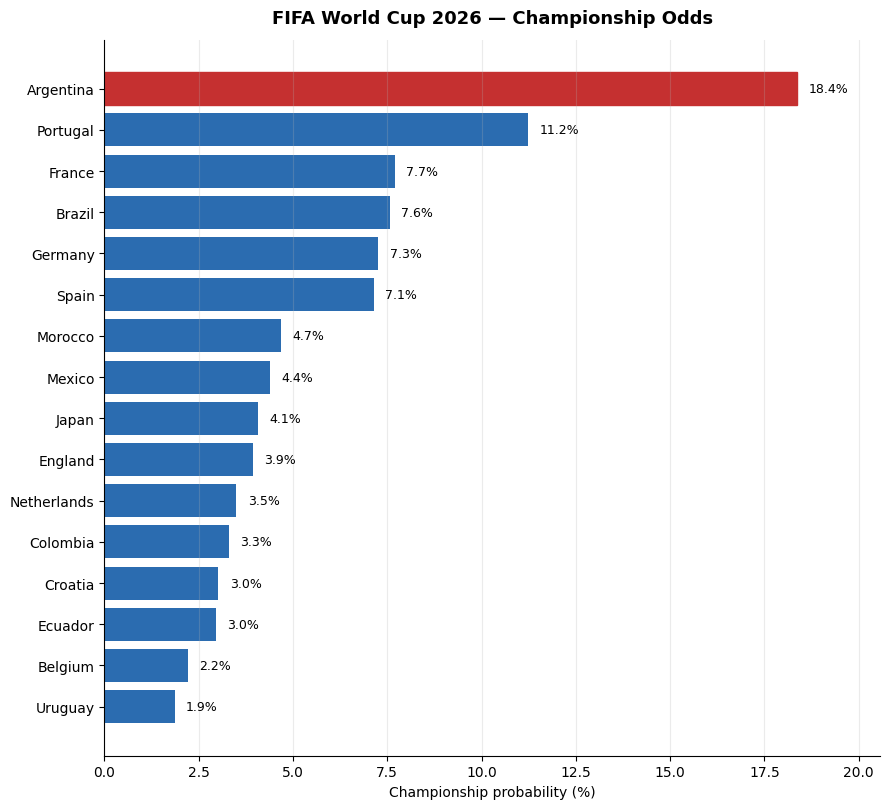

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_title_odds(odds, top_n=16, title="FIFA World Cup 2026 — Championship Odds"):
    if isinstance(odds, dict):
        s = pd.Series(odds, dtype=float)
    elif isinstance(odds, pd.DataFrame):
        cols = list(odds.columns)
        team_col = next((c for c in cols if any(k in c.lower() for k in ("team", "country"))), cols[0])
        prob_col = next((c for c in cols if any(k in c.lower() for k in ("odd", "prob", "win", "champ"))), cols[-1])
        s = odds.set_index(team_col)[prob_col].astype(float)
    else:
        s = pd.Series(odds, dtype=float)

    s = s[s > 0].dropna()
    print(f"[debug] type={type(odds).__name__}  teams={len(s)}  "
          f"sum={s.sum():.4g}  max={s.max() if len(s) else 'n/a'}")
    if s.empty:
        print("Nothing to plot — `odds` came in empty/zero. Check the print above and what you passed.")
        return

    if s.max() > 1.5:                       # counts/percentages -> fractions
        s = s / s.sum()
    s = s.sort_values(ascending=False).head(top_n).sort_values()

    fig, ax = plt.subplots(figsize=(9, 0.45 * len(s) + 1))
    bars = ax.barh(s.index.astype(str), s.values * 100, color="#2b6cb0")
    bars[-1].set_color("#c53030")
    for b, v in zip(bars, s.values * 100):
        ax.text(v + 0.3, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", fontsize=9)
    ax.set_xlabel("Championship probability (%)")
    ax.set_title(title, fontsize=13, weight="bold", pad=12)
    ax.margins(x=0.12)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_title_odds(champions)

### Saving the model

In [28]:
import joblib

artifacts = {
    "model":     model,
    "elos":      dict(elos),
    "form":      {k: list(v) for k, v in form.items()},   # lists -> clean pickle
    "FEATURES":  list(FEATURES),
    "HOME_ADV":  HOME_ADV,
    "classes":   list(model.classes_),
    "teams":     sorted(elos.keys()),
    "champions": dict(champions),
}
joblib.dump(artifacts, "wc2026_artifacts.joblib")
print("saved:", {k: type(v).__name__ for k, v in artifacts.items()})

saved: {'model': 'XGBClassifier', 'elos': 'dict', 'form': 'dict', 'FEATURES': 'list', 'HOME_ADV': 'int', 'classes': 'list', 'teams': 'list', 'champions': 'dict'}


In [29]:
import inspect
print(inspect.getsource(predict_match))

def predict_match(home, away, neutral=True):
    he = elos.get(home, 1500.0)
    ae = elos.get(away, 1500.0)
    hf = np.mean(form[home]) if form.get(home) else 0.0
    af = np.mean(form[away]) if form.get(away) else 0.0
    elo_diff = (he + (0 if neutral else HOME_ADV)) - ae
    x = pd.DataFrame([[elo_diff, he, ae, int(neutral), hf, af, hf - af]], columns=FEATURES)
    p = model.predict_proba(x)[0]
    return {"home_win": round(float(p[0]),3), "draw": round(float(p[1]),3), "away_win": round(float(p[2]),3)}



### Feature.py

In [30]:
import joblib, numpy as np, pandas as pd

_A = joblib.load("wc2026_artifacts.joblib")
MODEL, ELOS, FORM = _A["model"], _A["elos"], _A["form"]
FEATURES, HOME_ADV = _A["FEATURES"], _A["HOME_ADV"]
TEAMS, CHAMPIONS = _A["teams"], _A["champions"]

def predict_match(home, away, neutral=True):
    he = ELOS.get(home, 1500.0)
    ae = ELOS.get(away, 1500.0)
    hf = np.mean(FORM[home]) if FORM.get(home) else 0.0
    af = np.mean(FORM[away]) if FORM.get(away) else 0.0
    elo_diff = (he + (0 if neutral else HOME_ADV)) - ae
    x = pd.DataFrame([[elo_diff, he, ae, int(neutral), hf, af, hf - af]], columns=FEATURES)
    p = MODEL.predict_proba(x)[0]
    return {"home_win": round(float(p[0]), 3),
            "draw":     round(float(p[1]), 3),
            "away_win": round(float(p[2]), 3)}

def championship_odds(top=None):
    total = sum(CHAMPIONS.values()) or 1
    items = sorted(((t, c / total) for t, c in CHAMPIONS.items()), key=lambda x: -x[1])
    return items[:top] if top else items

### api.py

In [31]:
!pip install fastapi


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from fastapi import FastAPI, HTTPException
import features as F

app = FastAPI(title="WC 2026 Predictor")

@app.get("/teams")
def teams():
    return {"teams": F.TEAMS}

@app.get("/predict")
def predict(home: str, away: str):
    if home not in F.ELOS or away not in F.ELOS:
        raise HTTPException(404, "unknown team")
    if home == away:
        raise HTTPException(400, "pick two different teams")
    return {"home": home, "away": away, "probs": F.predict_match(home, away)}

@app.get("/odds")
def odds(top: int = 16):
    return {"odds": [{"team": t, "prob": p} for t, p in F.championship_odds(top)]}

In [33]:
%%writefile features.py
import joblib, numpy as np, pandas as pd

_A = joblib.load("wc2026_artifacts.joblib")
MODEL, ELOS, FORM = _A["model"], _A["elos"], _A["form"]
FEATURES, HOME_ADV = _A["FEATURES"], _A["HOME_ADV"]
TEAMS, CHAMPIONS = _A["teams"], _A["champions"]

def predict_match(home, away, neutral=True):
    he = ELOS.get(home, 1500.0)
    ae = ELOS.get(away, 1500.0)
    hf = np.mean(FORM[home]) if FORM.get(home) else 0.0
    af = np.mean(FORM[away]) if FORM.get(away) else 0.0
    elo_diff = (he + (0 if neutral else HOME_ADV)) - ae
    x = pd.DataFrame([[elo_diff, he, ae, int(neutral), hf, af, hf - af]], columns=FEATURES)
    p = MODEL.predict_proba(x)[0]
    return {"home_win": round(float(p[0]), 3),
            "draw":     round(float(p[1]), 3),
            "away_win": round(float(p[2]), 3)}

def championship_odds(top=None):
    total = sum(CHAMPIONS.values()) or 1
    items = sorted(((t, c / total) for t, c in CHAMPIONS.items()), key=lambda x: -x[1])
    return items[:top] if top else items

Overwriting features.py


In [34]:
%%writefile api.py
from fastapi import FastAPI, HTTPException
import features as F

app = FastAPI(title="WC 2026 Predictor")

@app.get("/teams")
def teams():
    return {"teams": F.TEAMS}

@app.get("/predict")
def predict(home: str, away: str):
    if home not in F.ELOS or away not in F.ELOS:
        raise HTTPException(404, "unknown team")
    if home == away:
        raise HTTPException(400, "pick two different teams")
    return {"home": home, "away": away, "probs": F.predict_match(home, away)}

@app.get("/odds")
def odds(top: int = 16):
    return {"odds": [{"team": t, "prob": p} for t, p in F.championship_odds(top)]}

Overwriting api.py


In [35]:
%%writefile app.py
import requests, pandas as pd, streamlit as st, altair as alt

API = "http://localhost:8000"
st.set_page_config(page_title="World Cup 2026 Predictor", page_icon="⚽", layout="centered")
st.title("⚽ FIFA World Cup 2026 Predictor")

@st.cache_data(ttl=300)
def get(path, **params):
    return requests.get(f"{API}{path}", params=params, timeout=15).json()

teams = get("/teams")["teams"]
st.subheader("Match predictor")
c1, c2 = st.columns(2)
home = c1.selectbox("Home", teams, index=0)
away = c2.selectbox("Away", teams, index=1)

if st.button("Predict", type="primary"):
    if home == away:
        st.warning("Pick two different teams.")
    else:
        p = requests.get(f"{API}/predict", params={"home": home, "away": away}, timeout=15).json()["probs"]
        df = pd.DataFrame({"outcome": [f"{home} win", "Draw", f"{away} win"],
                           "p": [p["home_win"], p["draw"], p["away_win"]]})
        st.altair_chart(alt.Chart(df).mark_bar(color="#2b6cb0").encode(
            x=alt.X("p:Q", axis=alt.Axis(format="%"), title="probability"),
            y=alt.Y("outcome:N", sort="-x", title=None)).properties(height=150),
            use_container_width=True)

st.divider()
st.subheader("Championship odds")
top = st.slider("Show top", 5, 32, 16)
odf = pd.DataFrame(get("/odds", top=top)["odds"])
st.altair_chart(alt.Chart(odf).mark_bar(color="#2b6cb0").encode(
    x=alt.X("prob:Q", axis=alt.Axis(format="%"), title="title probability"),
    y=alt.Y("team:N", sort="-x", title=None)).properties(height=22 * len(odf)),
    use_container_width=True)

Overwriting app.py


In [36]:
import features as F
F.predict_match("Argentina", "Brazil")

{'home_win': 0.403, 'draw': 0.297, 'away_win': 0.3}

In [37]:
import pandas as pd, streamlit as st, altair as alt
import features as F

st.set_page_config(page_title="World Cup 2026 Predictor", page_icon="⚽", layout="centered")
st.title("⚽ FIFA World Cup 2026 Predictor")

teams = F.TEAMS
st.subheader("Match predictor")
c1, c2 = st.columns(2)
home = c1.selectbox("Home", teams, index=0)
away = c2.selectbox("Away", teams, index=1)

if st.button("Predict", type="primary"):
    if home == away:
        st.warning("Pick two different teams.")
    else:
        p = F.predict_match(home, away)
        df = pd.DataFrame({"outcome": [f"{home} win", "Draw", f"{away} win"],
                           "p": [p["home_win"], p["draw"], p["away_win"]]})
        st.altair_chart(alt.Chart(df).mark_bar(color="#2b6cb0").encode(
            x=alt.X("p:Q", axis=alt.Axis(format="%"), title="probability"),
            y=alt.Y("outcome:N", sort="-x", title=None)).properties(height=150),
            use_container_width=True)

st.divider()
st.subheader("Championship odds")
top = st.slider("Show top", 5, 32, 16)
odf = pd.DataFrame(F.championship_odds(top), columns=["team", "prob"])
st.altair_chart(alt.Chart(odf).mark_bar(color="#2b6cb0").encode(
    x=alt.X("prob:Q", axis=alt.Axis(format="%"), title="title probability"),
    y=alt.Y("team:N", sort="-x", title=None)).properties(height=22 * len(odf)),
    use_container_width=True)

2026-06-16 23:33:38.755 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 23:33:38.757 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 23:33:39.941 
  command:

    streamlit run C:\Users\ESHAN JAIN\.conda\envs\ml_env\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-16 23:33:39.942 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 23:33:39.943 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 23:33:39.944 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 23:33:39.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ign

DeltaGenerator()